## Simulation forward-model — step-by-step flow diagram

A reviewer noted that the forward-model / simulation pipeline (spectra,
filter transmission, pixel-dependent QE, photon statistics, read noise, PSF
width, and detector pattern) is currently described only by equations in the
Supplementary Notes, and would benefit from a step-by-step diagram or
algorithmic description of how these combine to generate (a) simulated raw
data and (b) predicted spectral fingerprints.

This notebook produces two complementary SI figure assets, each panel saved
as its own SVG in `./figures/` so it can be dropped directly into the
Supplementary Notes next to the corresponding equations:

1. **Worked-example panels (A-J)** — one per pipeline stage, each showing
   that stage's concrete effect on real spectra/PSF data, in the same
   minimal style as the existing `Three_Dye_Spectra.svg` /
   `Three_Dye_Ratios.svg` panels in `Ternary_Plot_SingleMolecules.ipynb`.
2. **Flow diagram** — a schematic box/arrow summary of the whole pipeline,
   showing the two shared early stages (spectrum, filter, QE) branching into
   the spectral-fingerprint path and the raw-data path.

This is a forward-simulation-only notebook (no fitting/analysis), so it
does not import `FittingStrategy`/`Image_Analysis_Functions` at all.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import os
from pathlib import Path
import sys

sys.path.append('../../..')
from src import SpectralFunctions, MaskFunctions, PSFFunctions, IOFunctions
from src import PlottingBase
from src.SpectralFunctions import SpectralDataType

S_F     = SpectralFunctions.Spectral_Funcs()
M_F     = MaskFunctions.Mask_Functions(camera='ximea')
PSF     = PSFFunctions.PSF_Functions()
IO      = IOFunctions.IO_Functions()
plotter = PlottingBase.PublicationPlotter(dark_background=False)

FIGURE_DIR = Path('./figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
# ── Shared example data ──────────────────────────────────────────────────────
CAL_DIR = '../../../Camera_Calibrations/Ximea_Camera/'
R, G, B, wavelength = S_F.getpixelefficiency()

# Same trio as Three_Dye_Spectra.svg / Three_Dye_Ratios.svg, for visual
# continuity with the other SI figures.
example_dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
dye_colours  = ["#99ff99", "#ffc04d", "#ff6666"]

# Real multi-notch filter matching this project's actual optics (confirmed
# present in the spectral DB: S_F.db_handler.get_available_names(...)).
EXAMPLE_FILTER = ['semrock-nf03-405-488-561-635e']
NA             = 1.49
PIXEL_SIZE_UM  = 0.069   # Ximea, matches Camera_Calibrations/Ximea_Camera/

gain_map     = IO.read_tiff(os.path.join(CAL_DIR, 'gain.tif'))
offset_map   = IO.read_tiff(os.path.join(CAL_DIR, 'offset.tif'))
variance_map = IO.read_tiff(os.path.join(CAL_DIR, 'variance.tif'))

print(f'wavelength grid: {wavelength.min():.0f}-{wavelength.max():.0f} nm, {len(wavelength)} points')
print(f'calibration maps: {gain_map.shape}')


wavelength grid: 400-999 nm, 600 points
calibration maps: (1544, 2064)


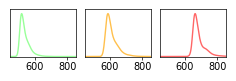

In [5]:
# ── Panel A -- dye emission spectra ─────────────────────────────────────────
spectrum = np.squeeze(S_F.get_dye_or_filter_data(names=example_dyes, wavelength=wavelength))

fig, axs = plotter.two_column_plot(ncols=3, width_ratios=list(np.ones(3)), width=2.25, height=0.7)
for i in range(3):
    axs[i] = plotter.line_plot(axs[i], wavelength, spectrum[i, :], color=dye_colours[i])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_yticklabels('')
    axs[i].set_ylim([0, np.max(spectrum[i, :]) * 1.1])
    axs[i].grid(False)
    axs[i].set_yticks([])
    axs[i].set_xlim([450, 850])

plt.savefig(FIGURE_DIR / 'panelA_spectra.svg', format='svg', dpi=600)
plt.show()


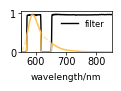

In [6]:
# ── Panel B -- filter transmission truncates the spectrum ──────────────────
filter_transmission = np.squeeze(
    S_F.get_spectral_data(EXAMPLE_FILTER, wavelength, SpectralDataType.FILTER)
)
if filter_transmission.ndim > 1:
    filter_transmission = np.prod(filter_transmission, axis=0)

fig, ax = plotter.one_column_plot(height=0.8, width=1.1)
ax.plot(wavelength, filter_transmission, color='k', lw=1.0, label='filter')
for i, dye in enumerate(example_dyes):
    if i == 1:
        spec_norm = spectrum[i, :] / np.max(spectrum[i, :])
        ax.plot(wavelength, spec_norm, color=dye_colours[i], lw=1.0, alpha=0.45, ls='--')
        ax.plot(wavelength, spec_norm * filter_transmission, color=dye_colours[i], lw=1.0)
ax.set_xlim([550, 850])
ax.set_ylim([0, 1.05])
ax.set_xlabel('wavelength/nm', fontsize=6.5)
ax.set_ylabel('')
ax.legend(loc='upper right', fontsize=6, frameon=False)

plt.savefig(FIGURE_DIR / 'panelB_filter_truncation.svg', format='svg', dpi=600)
plt.show()


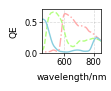

In [32]:
# ── Panel C -- pixel-dependent QE (Bayer-filtered pixel response) ──────────
fig, ax = plotter.one_column_plot(height=0.8, width=1)
ax = plotter.line_plot(ax, x=wavelength, y=R, color='#ffaaaaff', linestyle='-.',
                        xlabel='wavelength/nm', ylabel='QE')
ax = plotter.line_plot(ax, x=wavelength, y=G, color='#b3ff80ff', linestyle='--',
                        xlabel='wavelength/nm', ylabel='QE')
ax = plotter.line_plot(ax, x=wavelength, y=B, color='#87cddec7',
                        xlabel='wavelength/nm', ylabel='QE')
ax.set_xlim([450, 850])
ax.set_ylim([0, 0.7])
ax.set_xlabel('wavelength/nm', fontsize=6.5)
ax.tick_params(axis='x', labelsize=6) # Set size here
ax.tick_params(axis='y', labelsize=6) # Set size here
ax.set_ylabel('QE', fontsize=6.5)

plt.savefig(FIGURE_DIR / 'panelC_pixel_QE.svg', format='svg', dpi=600)
plt.show()


mean emission wavelengths (nm): [534.3 609.7 691.3]
R:G:B fractions (rows=dyes):
 [[0.104 0.743 0.153]
 [0.565 0.406 0.029]
 [0.71  0.221 0.069]]


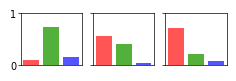

In [8]:
# ── Panel D -- combining spectrum x filter x QE -> spectral fingerprint ────
avg_wl, RGB_fractions = S_F.get_pixel_fractions_dye_and_filters(
    dyes=example_dyes, filters=EXAMPLE_FILTER, wavelength=wavelength,
    pixel_QYs=np.vstack([R, G, B]), normalized=True,
)
RGB_fractions = RGB_fractions.T / np.sum(RGB_fractions, axis=1)
RGB_fractions = RGB_fractions.T

print('mean emission wavelengths (nm):', np.round(avg_wl, 1))
print('R:G:B fractions (rows=dyes):\n', np.round(RGB_fractions, 3))

fig, axs = plotter.two_column_plot(ncols=3, width_ratios=list(np.ones(3)), width=2.25, height=0.7)
channel_colours = ['#ff5555', '#53b03b', '#5555ff']
for i in range(3):
    axs[i].bar(np.arange(3), RGB_fractions[i, :], color=channel_colours)
    axs[i].set_xticks([])
    axs[i].set_yticks([0, 1])
    axs[i].set_ylim([0, 1])
    if i != 0:
        axs[i].set_yticklabels('')
    axs[i].grid(False)

plt.savefig(FIGURE_DIR / 'panelD_fingerprint_bars.svg', format='svg', dpi=600)
plt.show()


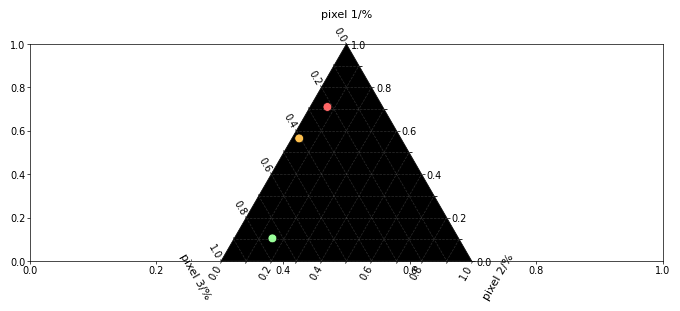

In [9]:
# ── Panel D (cont.) -- spectral fingerprints placed on the colour ternary ──
import mpltern
from matplotlib.ticker import MultipleLocator

fig, ax = plotter.two_column_plot()
ax = fig.add_subplot(1, 1, 1, projection='ternary')
ax.set_facecolor('black')

for taxis in (ax.taxis, ax.laxis, ax.raxis):
    taxis.set_major_locator(MultipleLocator(0.2))
    taxis.set_minor_locator(MultipleLocator(0.1))

ax.set_tlabel(r'pixel 1/%')
ax.set_llabel(r'pixel 3/%')
ax.set_rlabel(r'pixel 2/%')
ax.grid(lw=0.5, alpha=0.25, ls='--', which='both', axis='both')

Rd = RGB_fractions[:, 0] * 100
Gd = RGB_fractions[:, 1] * 100
Bd = RGB_fractions[:, 2] * 100
ax.scatter(Rd, Gd, Bd, s=40, c=dye_colours, edgecolors='k', lw=0.5, marker='o')

ax.set_tlim(0, 100)
ax.set_llim(0, 100)
ax.set_rlim(0, 100)

plt.savefig(FIGURE_DIR / 'panelD_fingerprint_ternary.svg', format='svg', dpi=600)
plt.show()


/tmp/ipykernel_936186/3804909288.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(fontsize=5.5, frameon=False)
/tmp/ipykernel_936186/3804909288.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


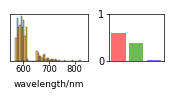

In [22]:
# ── Panel E -- photon statistics: shot noise on the spectral fingerprint ───
rng = np.random.default_rng(42)
example_idx = 1   # ATTO 565
dye_spectrum_filtered = spectrum[example_idx, :] * filter_transmission

N_PHOTONS_EXAMPLE = 500
photon_wl = S_F.sample_photons_from_spectrum(
    dye_spectrum_filtered, wavelength, N_PHOTONS_EXAMPLE, random_state=rng,
)
_, ratios = S_F.calculate_colourratio_from_photon_wavelengths(
    photon_wl, wavelength, pixel_QYs=np.vstack([R, G, B]),
)
ref_ratio = RGB_fractions[example_idx, :]   # deterministic Panel D value for this dye

fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1.4, 1], width=1.75, height=1)

# left: histogram of the sampled photon wavelengths
axs[0].hist(photon_wl, bins=50, color=dye_colours[example_idx], alpha=0.8, edgecolor='k', linewidth=0.3)
axs[0].set_xlim([550, 850])
axs[0].tick_params(axis='x', labelsize=6) # Set size here
axs[0].set_xlabel('wavelength/nm', fontsize=6.5)
axs[0].set_yticks([])

# right: this draw's realised channel fractions vs the deterministic prediction
channel_colours = ['#ff5555', '#53b03b', '#5555ff']
x = np.arange(3)
axs[1].bar(x, ratios, color=channel_colours, alpha=0.85)
axs[1].set_xticks([])
axs[1].set_yticks([0, 1])
axs[1].set_ylim([0, 1])
axs[1].legend(fontsize=5.5, frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'panelE_photon_statistics.svg', format='svg', dpi=600)
plt.show()


mean emission wavelength: 609.7 nm -> sigma_PSF = 92.1 nm = 1.33 px


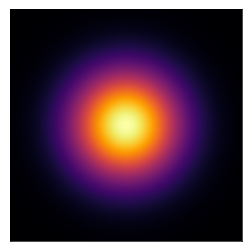

In [9]:
# ── Panel F -- PSF width, before pixellation ────────────────────────────────
mean_wl_dye_nm = float(avg_wl[example_idx])
sigma_psf_um   = float(PSF.sigma_PSF(mean_wl_dye_nm / 1000.0, NA))
sigma_psf_px   = sigma_psf_um / PIXEL_SIZE_UM
print(f'mean emission wavelength: {mean_wl_dye_nm:.1f} nm -> '
      f'sigma_PSF = {sigma_psf_um * 1000:.1f} nm = {sigma_psf_px:.2f} px')

GRID_SIZE_PX = 8
OVERSAMPLE   = 20

x_fine = np.linspace(-GRID_SIZE_PX / 2, GRID_SIZE_PX / 2, GRID_SIZE_PX * OVERSAMPLE)
y_fine = np.linspace(-GRID_SIZE_PX / 2, GRID_SIZE_PX / 2, GRID_SIZE_PX * OVERSAMPLE)
psf_fine = PSF.gen_spatial_PSF(
    x_fine, y_fine, sigma_psf_px, sigma_psf_px,
    np.array([0.0]), np.array([0.0]),
    n_photons=np.array([2000.0]),
    relative_QE=np.ones((len(x_fine), len(y_fine))),
)

fig, ax = plotter.one_column_plot(height=2.4)
ax.imshow(psf_fine.T, cmap='inferno', origin='lower',
          extent=[x_fine[0], x_fine[-1], y_fine[0], y_fine[-1]])
ax.set_xticks([])
ax.set_yticks([])

plt.savefig(FIGURE_DIR / 'panelF_psf_continuous.svg', format='svg', dpi=600)
plt.show()


per-channel absolute QE (R,G,B): [0.496 0.361 0.024]


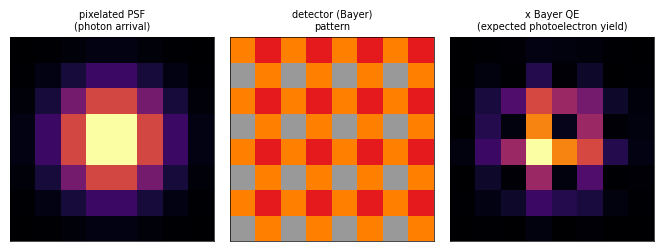

In [10]:
# ── Panel G -- detector pattern: pixelation + Bayer/CFA mask ───────────────
x_px = np.arange(-GRID_SIZE_PX / 2, GRID_SIZE_PX / 2) + 0.5
y_px = np.arange(-GRID_SIZE_PX / 2, GRID_SIZE_PX / 2) + 0.5
psf_pixelated = PSF.gen_spatial_PSF(
    x_px, y_px, sigma_psf_px, sigma_psf_px,
    np.array([0.0]), np.array([0.0]),
    n_photons=np.array([2000.0]),
    relative_QE=np.ones((len(x_px), len(y_px))),
)

bayer_masks = M_F.get_masks(len(x_px), len(y_px))
CHANNEL_ORDER = ['R', 'G', 'B']   # confirmed keys: bayer_masks.keys() == {'R','G','B'}
bayer_pattern_img = np.zeros((len(x_px), len(y_px)))
for code, ch in enumerate(CHANNEL_ORDER):
    bayer_pattern_img[bayer_masks[ch]] = code

# Absolute (unnormalised) per-channel QE for this dye -- the expected
# photon -> photoelectron conversion probability for a pixel of channel c.
# Photon *arrival* is spatially uniform (that's the plain pixelated PSF,
# left panel); the Bayer pattern doesn't change where photons land, it sets
# how efficiently each pixel converts what it receives. Mapping abs_QE per
# channel onto the mask and multiplying by the pixelated PSF is exactly
# what 'applying the detector pattern' means, and is the panel that should
# show Bayer/checkerboard structure -- reused as abs_QE_map in Panel H for
# the actual (stochastic) photoelectron conversion.
_, abs_QE_per_channel = S_F.get_pixel_fractions_dye_and_filters(
    dyes=[example_dyes[example_idx]], filters=EXAMPLE_FILTER, wavelength=wavelength,
    pixel_QYs=np.vstack([R, G, B]), normalized=False,
)
print(f'per-channel absolute QE (R,G,B): {np.round(abs_QE_per_channel, 3)}')

abs_QE_map = np.zeros_like(psf_pixelated)
for c, ch in enumerate(CHANNEL_ORDER):
    abs_QE_map[bayer_masks[ch]] = abs_QE_per_channel[c]

qe_weighted_psf = psf_pixelated * abs_QE_map   # expected photoelectron yield per pixel

fig, axs = plotter.two_column_plot(ncols=3, width_ratios=[1, 1, 1], width=6.6, height=2.4)
axs[0].imshow(psf_pixelated.T, cmap='inferno', origin='lower')
axs[0].set_title('pixelated PSF\n(photon arrival)', fontsize=7)
axs[1].imshow(bayer_pattern_img.T, cmap='Set1', origin='lower')
axs[1].set_title('detector (Bayer)\npattern', fontsize=7)
axs[2].imshow(qe_weighted_psf.T, cmap='inferno', origin='lower')
axs[2].set_title('x Bayer QE\n(expected photoelectron yield)', fontsize=7)
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig(FIGURE_DIR / 'panelG_detector_pattern.svg', format='svg', dpi=600)
plt.show()


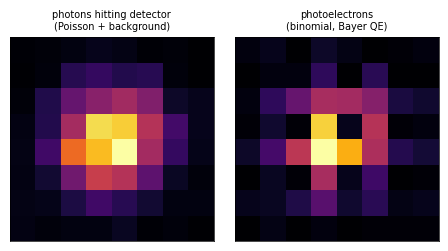

In [11]:
# ── Panel H -- photon shot noise at the detector, then photoelectron (QE) ──
BACKGROUND_PHOTONS = 5.0   # per-pixel background rate
photon_counts = PSF.gen_photons_hitting_detector(psf_pixelated, background=BACKGROUND_PHOTONS)

# Per-pixel channel QE (abs_QE_map, built in Panel G) -- this is where the
# Bayer pattern actually enters the simulated raw image: photon arrival is
# spatially uniform, but each pixel's photon -> photoelectron conversion
# probability depends on its channel, so the result below shows genuine
# Bayer/checkerboard texture.
photoelectrons = PSF.gen_photoelectrons(photon_counts, abs_QE_map)

fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1], width=4.5, height=2.4)
axs[0].imshow(photon_counts.T, cmap='inferno', origin='lower')
axs[0].set_title('photons hitting detector\n(Poisson + background)', fontsize=7)
axs[1].imshow(photoelectrons.T, cmap='inferno', origin='lower')
axs[1].set_title('photoelectrons\n(binomial, Bayer QE)', fontsize=7)
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig(FIGURE_DIR / 'panelH_photon_to_photoelectron.svg', format='svg', dpi=600)
plt.show()


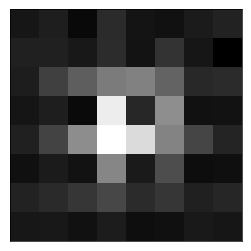

In [12]:
# ── Panel I -- read noise (gain/offset/variance) -> final raw ADU image ────
gh, gw = gain_map.shape
cy, cx = gh // 2, gw // 2
half = GRID_SIZE_PX // 2
gain_crop     = gain_map[cy - half:cy + half, cx - half:cx + half].astype(np.float64)
offset_crop   = offset_map[cy - half:cy + half, cx - half:cx + half].astype(np.float64)
variance_crop = variance_map[cy - half:cy + half, cx - half:cx + half].astype(np.float64)

raw_image = PSF.photoelectrons_to_image(
    photoelectrons.astype(np.float64), gain_crop, offset_crop, variance_crop,
)

fig, ax = plotter.one_column_plot(height=2.4)
ax.imshow(raw_image.T, cmap='gray', origin='lower')
ax.set_xticks([])
ax.set_yticks([])

plt.savefig(FIGURE_DIR / 'panelI_raw_adu_image.svg', format='svg', dpi=600)
plt.show()


/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/SI/../../../src/PlottingBase.py:452: UserWarning: Width 12.00" exceeds two-column standard (6.69")
  warnings.warn(


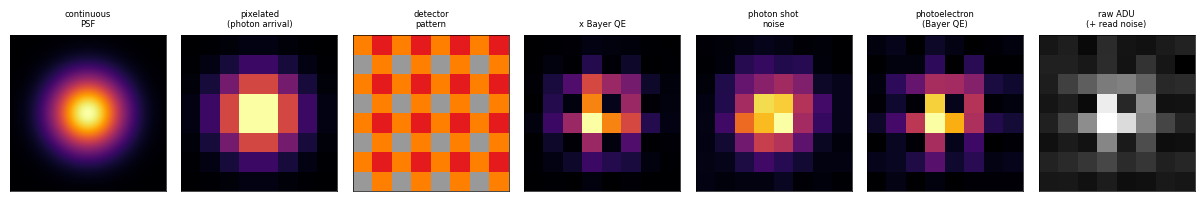

In [13]:
# ── Panel J -- putting it together: raw-data pipeline for one molecule ─────
fig, axs = plotter.two_column_plot(ncols=7, width_ratios=list(np.ones(7)), width=12.0, height=1.9)
panel_images = [psf_fine, psf_pixelated, bayer_pattern_img, qe_weighted_psf,
                photon_counts, photoelectrons, raw_image]
panel_titles = ['continuous\nPSF', 'pixelated\n(photon arrival)', 'detector\npattern',
                'x Bayer QE', 'photon shot\nnoise', 'photoelectron\n(Bayer QE)',
                'raw ADU\n(+ read noise)']
panel_cmaps  = ['inferno', 'inferno', 'Set1', 'inferno', 'inferno', 'inferno', 'gray']

for ax, img, title, cmap in zip(axs, panel_images, panel_titles, panel_cmaps):
    ax.imshow(img.T, cmap=cmap, origin='lower')
    ax.set_title(title, fontsize=6)
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig(FIGURE_DIR / 'panelJ_filmstrip.svg', format='svg', dpi=600)
plt.show()


### Flow diagram

Schematic summary of the pipeline demonstrated in Panels A-J above: the
first three stages (spectrum, filter transmission, pixel QE) are shared,
then the pipeline forks into the spectral-fingerprint path (top right,
Panels D-E) and the raw-data path (bottom left, Panels F-J).


/tmp/ipykernel_917433/4146247167.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


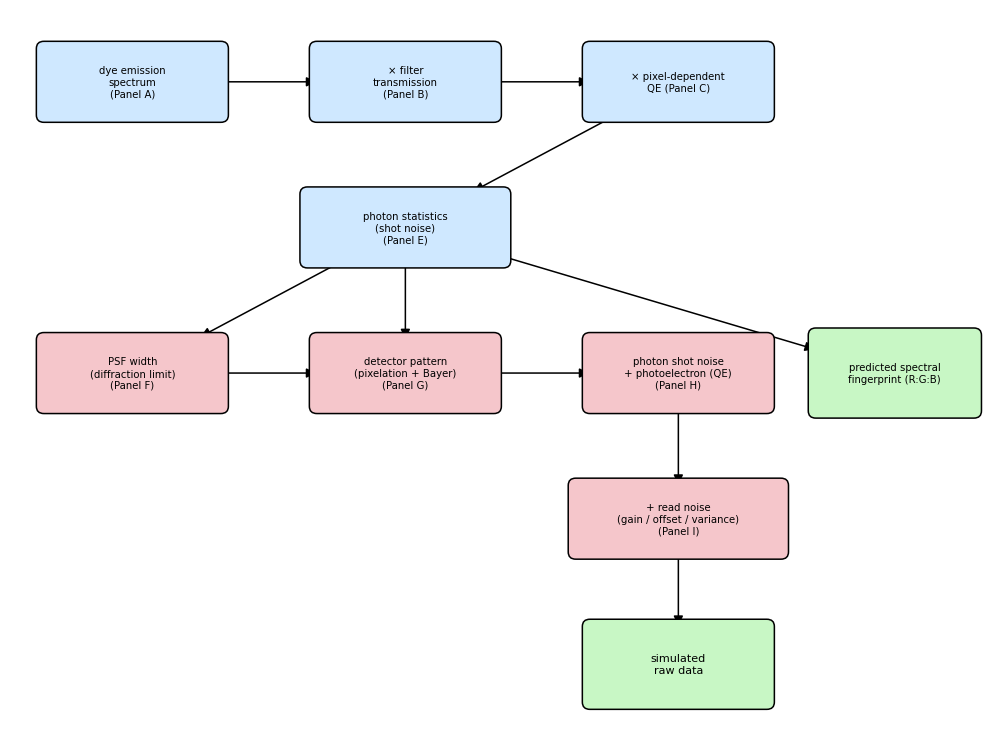

In [14]:
# ── Flow diagram: box/arrow schematic of the full pipeline ─────────────────
# Arrows are clipped to each box's actual rectangle boundary (plus a small
# margin) rather than shrunk by a fixed point offset from box centres -- a
# fixed-point shrink left the arrowhead sitting under the box's opaque
# facecolor (higher zorder), making it invisible.
fig, ax = plt.subplots(figsize=(10, 7.4))
ax.set_xlim(0, 10.4)
ax.set_ylim(-0.7, 7.2)
ax.axis('off')

SPEC_C    = '#cfe8ff'   # spectral-domain stages
SPATIAL_C = '#f5c6cb'   # spatial / detector-domain stages
OUTPUT_C  = '#c8f7c5'   # final outputs

node_boxes = {}   # name -> (x, y, w, h)


def add_node(name, x, y, w, h, text, colour, fontsize=7.3):
    box = FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.08',
        linewidth=1.1, edgecolor='black', facecolor=colour, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, zorder=3)
    node_boxes[name] = (x, y, w, h)


def edge_point(cx, cy, w, h, tx, ty, margin=0.08):
    """Point on the box (cx,cy,w,h) boundary along the direction to (tx,ty),
    pulled back by `margin` data units so the arrowhead sits in open space."""
    dx, dy = tx - cx, ty - cy
    dist = np.hypot(dx, dy)
    if dist == 0:
        return cx, cy
    ux, uy = dx / dist, dy / dist
    halfw, halfh = w / 2, h / 2
    ts = []
    if ux != 0:
        ts.append(halfw / abs(ux))
    if uy != 0:
        ts.append(halfh / abs(uy))
    t_edge = min(ts)
    ex, ey = cx + ux * t_edge, cy + uy * t_edge
    return ex - ux * margin, ey - uy * margin


def add_arrow(src, dst):
    x1, y1, w1, h1 = node_boxes[src]
    x2, y2, w2, h2 = node_boxes[dst]
    start = edge_point(x1, y1, w1, h1, x2, y2)
    end   = edge_point(x2, y2, w2, h2, x1, y1)
    arrow = FancyArrowPatch(
        start, end, arrowstyle='-|>', mutation_scale=14,
        linewidth=1.1, color='black', zorder=1,
    )
    ax.add_patch(arrow)


# Row 1 (shared spectral stages) -- generous 0.9-unit gaps between adjacent
# boxes so arrowheads have room to render.
add_node('spectrum', 1.3, 6.4, 2.0, 0.85, 'dye emission\nspectrum\n(Panel A)', SPEC_C)
add_node('filter',   4.2, 6.4, 2.0, 0.85, '× filter\ntransmission\n(Panel B)', SPEC_C)
add_node('qe',       7.1, 6.4, 2.0, 0.85, '× pixel-dependent\nQE (Panel C)', SPEC_C)

# Row 2: photon statistics is the SHARED fork point -- not a side branch.
# Shot noise (Poisson arrival, binomial QE thinning) is intrinsic to both
# downstream paths: it governs the stochastic photon-wavelength sampling that
# produces the spectral fingerprint (Panel E) *and* the Poisson/binomial
# noise applied later in the spatial chain (Panel H's photon shot noise +
# photoelectron step), so it sits upstream of both, fed by QE.
add_node('photstat', 4.2, 4.8, 2.2, 0.85, 'photon statistics\n(shot noise)\n(Panel E)', SPEC_C)

# Row 3: spatial/raw-data chain (fed by photon statistics -> PSF width), plus
# the spectral fingerprint output branching off the same fork point.
add_node('psf',         1.3, 3.2, 2.0, 0.85, 'PSF width\n(diffraction limit)\n(Panel F)', SPATIAL_C)
add_node('pattern',     4.2, 3.2, 2.0, 0.85, 'detector pattern\n(pixelation + Bayer)\n(Panel G)', SPATIAL_C)
add_node('shotqe',      7.1, 3.2, 2.0, 0.85, 'photon shot noise\n+ photoelectron (QE)\n(Panel H)', SPATIAL_C)
add_node('fingerprint', 9.4, 3.2, 1.8, 0.95, 'predicted spectral\nfingerprint (R:G:B)', OUTPUT_C, fontsize=7.3)

# Row 4 (spatial chain continues)
add_node('readnoise', 7.1, 1.6, 2.3, 0.85, '+ read noise\n(gain / offset / variance)\n(Panel I)', SPATIAL_C)

# Row 5 (spatial-chain output)
add_node('rawdata', 7.1, 0.0, 2.0, 0.95, 'simulated\nraw data', OUTPUT_C, fontsize=8)

# Arrows
add_arrow('spectrum', 'filter')
add_arrow('filter', 'qe')
add_arrow('qe', 'photstat')
add_arrow('photstat', 'psf')
add_arrow('photstat', 'fingerprint')
# Both PSF width (via the stochastic draw's mean wavelength) and detector
# pattern (via that same draw's per-channel colour ratios, which set the
# per-pixel QE used to build the Bayer-weighted response) are directly
# informed by the photon-statistics draw -- confirmed in the real simulation
# (src/simulation/multicolour.py's gen_camera_image_stack path): both
# mean_wl and colour_ratios come out of the SAME
# SpectralFunctions.generate_bootstrap_colour_ratios() call (built on
# sample_photons_from_spectrum, i.e. Panel E's own mechanism), not from one
# feeding the other.
add_arrow('photstat', 'pattern')
add_arrow('psf', 'pattern')
add_arrow('pattern', 'shotqe')
add_arrow('shotqe', 'readnoise')
add_arrow('readnoise', 'rawdata')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'flow_diagram.svg', format='svg', dpi=600)
plt.show()
